In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([1,2,3,4])
y = np.array([2,2.8,3.6,4.5])

In [3]:
n = len(x)
#================
#intialize parameters
#================
w = 0
b = 0 
np.random.seed(42)
w = np.random.rand()
b = np.random.rand()
learning_rate = 0.01
epochs = 100
cost_values = []
print(f"initail w : {w}")
print(f"initail b : {b}")
print(f"learning_rate : {learning_rate}")
print(f"epochs : {epochs}")
print("Training............")


initail w : 0.3745401188473625
initail b : 0.9507143064099162
learning_rate : 0.01
epochs : 100
Training............


In [4]:
#=======================
#Gradient Descent   
#======================
for i in range(epochs):
    y_hat = w * x + b
    error = y_hat - y
    #Gradients
    d_w = np.mean(error * x)
    d_b = np.mean(error)
    #update parameters
    w -= learning_rate * d_w
    b -= learning_rate * d_b
    #new line prediction
    y_hat = w*x +b   
    #cost
    cost = 0.5* np.mean((y_hat - y )**2)
    cost_values.append(cost)
    
    if (i +1) % 100 == 0 or i == 0:
        print(f"Epoch {i+1}:"
              f"cost = {cost},"
              f"w = {w}, "
              f"b = {b} ")
    
    
    
    
    
 

Epoch 1:cost = 0.8610994001541662,w = 0.4136817522735624, b = 0.964093660374633 
Epoch 100:cost = 0.00047292425592869545,w = 0.8415689418615291, b = 1.1157346132376187 


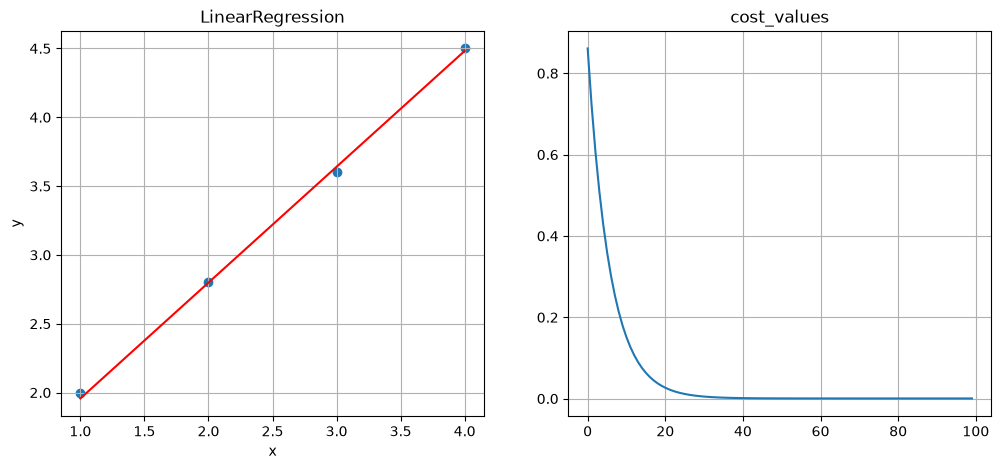

In [5]:
plt.figure(figsize=(12,5))
plt.subplot(1 , 2 , 1)
plt.scatter(x , y)
plt.plot(x , w*x + b , c = "red")
plt.title("LinearRegression")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()


plt.subplot(1 , 2 , 2)
plt.plot(cost_values)
plt.title("cost_values")
plt.grid()


In [6]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score , root_mean_squared_error

In [7]:
data = pd.read_csv(r"Salary_Data.csv")

In [8]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


c:\python\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<Figure size 300x400 with 0 Axes>

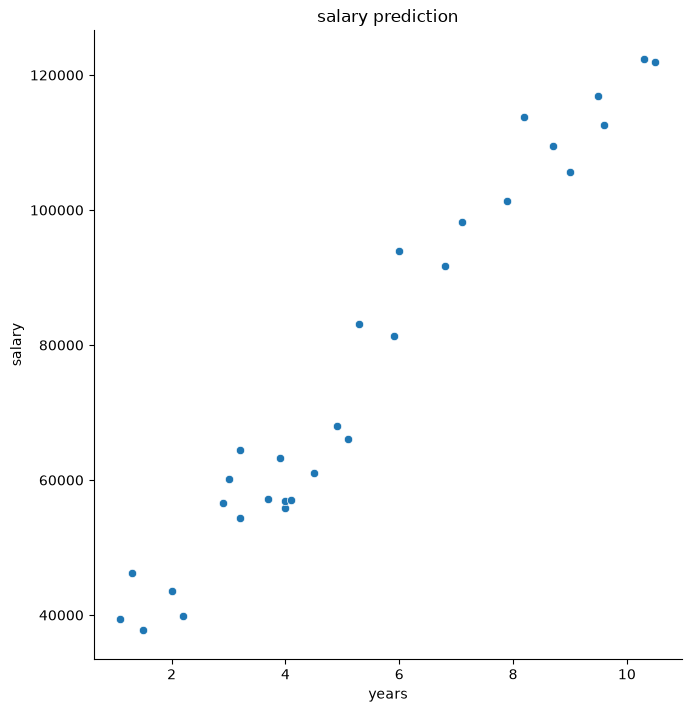

In [9]:
plt.figure(figsize=(3,4))
sns.pairplot(data , x_vars=["YearsExperience"] , y_vars= ["Salary"] , size = 7 , kind ="scatter")
plt.xlabel("years")
plt.ylabel("salary")
plt.title("salary prediction")
plt.show()

In [10]:
x = data.iloc[: , :-1]
y = data.iloc[: , 1]

In [11]:
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    train_size= 0.80,
    random_state= 10
)

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(x_train , y_train)
y_hat = lin_reg.predict(x_train)


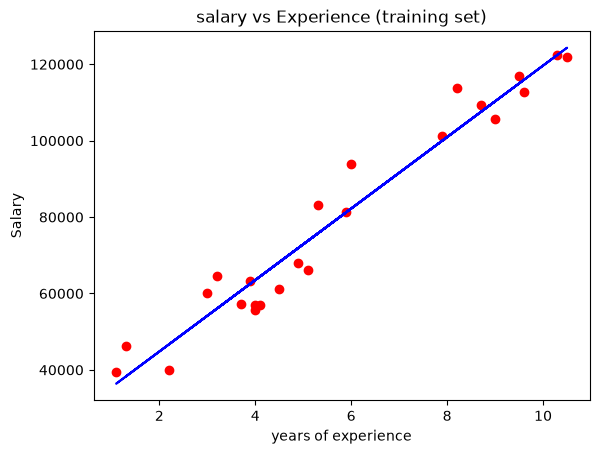

In [13]:
plt.scatter(x_train , y_train , c = "red")
plt.plot(x_train , y_hat , c = "blue")
plt.title("salary vs Experience (training set)")
plt.xlabel("years of experience")
plt.ylabel("Salary")
plt.show()

In [14]:
y_hat_test = lin_reg.predict(x_test)

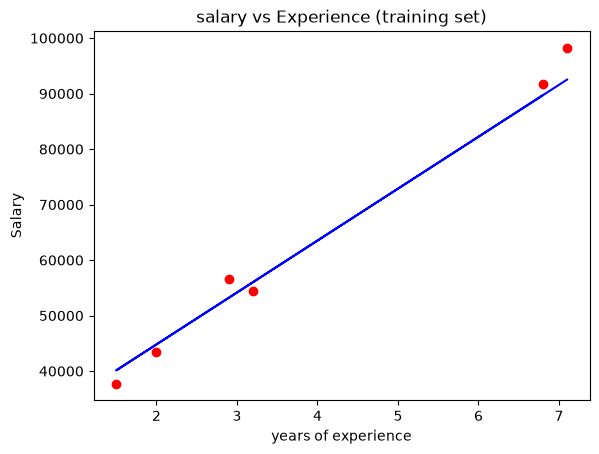

In [15]:
plt.scatter(x_test , y_test , c = "red")
plt.plot(x_test , y_hat_test , c = "blue")
plt.title("salary vs Experience (training set)")
plt.xlabel("years of experience")
plt.ylabel("Salary")
plt.show()

In [16]:
#calculate mean square error
mse = mean_squared_error(y_test , y_hat_test)
print(mse)
rmse = root_mean_squared_error(y_test , y_hat_test)
print(rmse)
r2 = r2_score(y_test , y_hat_test)
print(r2)

9785570.138914317
3128.189594464235
0.9816423482070253


In [17]:
bais = lin_reg.intercept_
bais

np.float64(26089.096632416724)

In [18]:
W = lin_reg.coef_
W

array([9356.86299354])

In [19]:
new_sal = W*10 + bais
new_sal

array([119657.72656781])

In [20]:
import numpy as np
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import mean_squared_error , r2_score

In [21]:
x = np.array([[1],[2] ,[3] ,[4] ])
y = np.array([2 , 4 , 6, 8])
#Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(x , y)
y_pred_lin = lin_reg.predict(x)# wx +b
#Ridge Regression
ridge = Ridge(alpha = 100.0)
ridge.fit(x , y)
y_pred_ridge = ridge.predict(x)
#lasso Regression
lasso = Lasso( alpha = 10.0)
lasso.fit(x,y)
y_pred_lasso = lasso.predict(x)

print("Linear Regression")
print(f"MSE : " , mean_squared_error(y , y_pred_lin))
print("R2:" , r2_score(y , y_pred_lin))
print("="*40)

print("Ridge Regression")
print(f"MSE : " , mean_squared_error(y , y_pred_ridge))
print("R2:" , r2_score(y , y_pred_ridge))
print("="*40)

print("Lasso Regression")
print(f"MSE : " , mean_squared_error(y , y_pred_lasso))
print("R2 help for feature selection:" , r2_score(y , y_pred_lasso))
print("="*40)

Linear Regression
MSE :  0.0
R2: 1.0
Ridge Regression
MSE :  4.53514739229025
R2: 0.09297052154194996
Lasso Regression
MSE :  5.0
R2 help for feature selection: 0.0


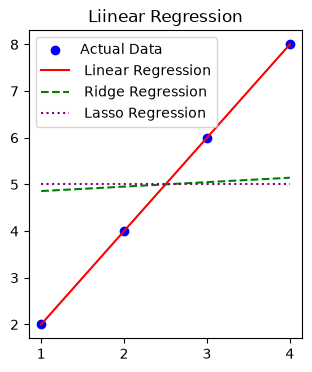

In [22]:
plt.figure(figsize=(12,4))
plt.subplot(1 , 3 , 1)
plt.scatter(x , y , c = "blue" , label = "Actual Data" )
plt.plot(x , y_pred_lin , c = "red" , label = " Linear Regression")
plt.plot(x , y_pred_ridge , c = "green" , linestyle ="--" , label = " Ridge Regression")
plt.plot(x , y_pred_lasso , c = "purple" ,linestyle = ":", label = " Lasso Regression")
plt.title("Liinear Regression")
plt.legend()


